# Extract Posterior Samples (data level)

Mostly personal use, turns posterior sampling data from h5py into csv with jacobian resampling  

In [8]:
import os
import pandas as pd
import h5py
import csv
import numpy as np
import psrqpy
import jax
import matplotlib.pyplot as plt

In [ ]:
'''
# clean datasets
for pulsar in dirs:
    pulsar_path = posterior_data_parent_dir + "/" + pulsar
    files = os.listdir(pulsar_path)
    for dataset in files:
        if not dataset.endswith('.hdf5'):
            os.remove(pulsar_path + "/" + dataset)
        elif "H1L1" not in dataset:
            os.remove(pulsar_path + '/' + dataset)
'''

In [ ]:


def create_sample_stack(distance_path, posterior_path):
    df = pd.read_csv(distance_path, header=None)
    df = df.T
    # contains pulsar names and distances
    # column 0 is pulsar names, column 1 is distance estimates

    posterior_data_parent_dir = posterior_path
    dirs = os.listdir(posterior_data_parent_dir)
    # dirs is now a list of all pulsars in sampled pulsar catalogue

    max_obs = 0

    freqs_arr = np.ones(45)
    ellips_arr = np.ones(45)
    pulsar_idx = 0

    # writes the output into csv file
    with open("eps_samples_stack.csv", mode='a', newline='',encoding = 'utf-8') as file:
        writer = csv.writer(file)        

        # going through each pulsar, generating epsilon values
        for pulsar in dirs:
            pulsar_path = os.path.join(posterior_data_parent_dir, pulsar)
            pulsar_data_file = os.listdir(pulsar_path)
            data_path = os.path.join(pulsar_path, pulsar_data_file[0])
            # opening data file
            with h5py.File(data_path,'r') as f:
                
                Nsamps = f['/posterior/h0'].shape[0]
                # this is the number of samps for each pulsar
                
                # sample for distances, normal dist with sigma 20% of mean:
                idx = df[df[0]==pulsar].index[0]
                # get row number of specific pulsar
                mean_dist = df.iat[idx,1]
                # get distance for that pulsar
                
                distances = np.random.normal(float(mean_dist), 0.2*float(mean_dist), Nsamps)
                # distribution of distances Nsamp long

                freq = psrqpy.QueryATNF(psrs=pulsar, params="F0").pandas.iat[0,0]

                epsilons = distances * f['/posterior/h0'][:] * (1e18 / 4.2) / (freq / 1000)**2
                # eps = D * h0

                # now lets resample based on the jacobian
                weight = distances
                eps_idx = np.random.choice(len(epsilons), size = len(epsilons), p = weight / np.sum(weight))


                epsilons_resampled = epsilons[eps_idx]

                freqs_arr[pulsar_idx] = freq
                ellip_upper_lim = np.percentile(epsilons,90)
                ellips_arr[pulsar_idx] = ellip_upper_lim

                pulsar_idx += 1


                if Nsamps > max_obs:
                    max_obs = Nsamps

                # numbeer of effective samples per obs
                log_weights = np.log(weight)
                neff = np.exp(2 * jax.nn.logsumexp(log_weights) - jax.nn.logsumexp(2 * log_weights))
                
                
                writer.writerow(epsilons_resampled)
                # write onto csv
                print('Pulsar: ' + pulsar + ' done. Number of samples:' + str(Nsamps) + '.  Number of effective samples: ' + str(neff))
        return max_obs, freqs_arr, ellips_arr

    

In [43]:
distance_path = "data/o4_pulsar_distances.csv"
posterior_path = "data/pulsar_posteriors"


max_obs, freqs_arr, ellips_arr = create_sample_stack(distance_path, posterior_path)


Pulsar: J0030+0451 done: 3336.  Number of effective obs: 3206.5425
Pulsar: J0058-7218 done: 2385.  Number of effective obs: 2295.4338
Pulsar: J0117+5914 done: 4075.  Number of effective obs: 3920.881
Pulsar: J0205+6449 done: 2742.  Number of effective obs: 2635.563
Pulsar: J0437-4715 done: 2723.  Number of effective obs: 2615.5977
Pulsar: J0534+2200 done: 2278.  Number of effective obs: 2190.6355
Pulsar: J0537-6910 done: 2203.  Number of effective obs: 2118.3928
Pulsar: J0540-6919 done: 2445.  Number of effective obs: 2351.072
Pulsar: J0614-3329 done: 3403.  Number of effective obs: 3276.0781
Pulsar: J0737-3039A done: 2362.  Number of effective obs: 2269.202
Pulsar: J0835-4510 done: 3412.  Number of effective obs: 3277.397
Pulsar: J1231-1411 done: 3454.  Number of effective obs: 3319.3142
Pulsar: J1412+7922 done: 2651.  Number of effective obs: 2547.0386
Pulsar: J1537+1155 done: 2277.  Number of effective obs: 2191.2874
Pulsar: J1623-2631 done: 3342.  Number of effective obs: 3211.0437

Text(0, 0.5, 'Ellipticity (90% Upper Limit)')

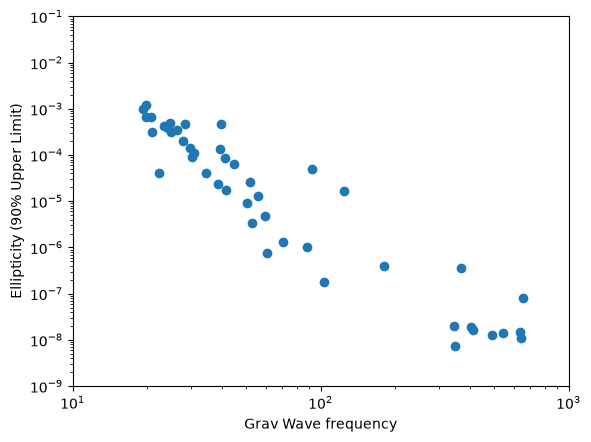

In [44]:
plt.scatter(freqs_arr * 2, ellips_arr)

plt.xlim(1e1, 1e3)
plt.ylim(1e-9, 1e-1)
plt.xscale('log')
plt.yscale('log')

plt.xlabel("Grav Wave frequency")
plt.ylabel("Ellipticity (90% Upper Limit)")



